# 02a · The weak form & test functions — *why* and *how*

Notebooks `02`, `02b`, `03b` *use* the weak form to beat conventional SINDy. This one explains the
machinery underneath, with no result to sell:

1. what the **strong form** of a differential equation is, and why it is fragile;
2. how the **weak (variational / Galerkin) form** is built — multiply by a *test function* and
   integrate by parts — for an **ODE** *and* a **PDE**;
3. the main **families of test functions**, their properties, and how to choose one.

The single idea to carry through: *the weak form moves every derivative off the (noisy, possibly
non-smooth) data and onto a smooth, known test function.*

In [1]:
import os, sys, warnings
warnings.filterwarnings("ignore")
def _add_src():
    here = os.getcwd()
    for base in [here, os.path.dirname(here), os.path.dirname(os.path.dirname(here))]:
        cand = os.path.join(base, "src")
        if os.path.isdir(os.path.join(cand, "sparse_demos")):
            if cand not in sys.path: sys.path.insert(0, cand)
            return
    raise RuntimeError("Could not locate src/sparse_demos")
_add_src()
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import eval_legendre
from scipy.integrate import solve_ivp
from sparse_demos import libraries, solvers, weak
%matplotlib inline
np.set_printoptions(suppress=True, precision=4)

## 1 · The strong form

The **strong form** is the differential equation written *pointwise* — it must hold at every point
$t$ (or $(x,t)$), and it requires the solution to be differentiable enough for every derivative in
it to exist.

* **ODE:** $\dfrac{dx}{dt}=f\big(x(t)\big)$ must hold at every $t$.
* **PDE (heat):** $\partial_t u(x,t)=\nu\,\partial_{xx}u(x,t)$ must hold at every $(x,t)$.

Two practical problems when we only have *sampled, noisy* data:

1. **Derivatives must be estimated pointwise.** A *centered* finite difference of data with noise
   std $\sigma$ has derivative-noise std $\sigma/(\sqrt2\,\Delta t)$ — noise *amplified* by
   $1/\Delta t$, and worse for second derivatives ($\sim\sigma/\Delta t^2$).
2. **The solution must actually be that smooth.** Shocks, kinks, and discontinuities have no
   classical pointwise derivative at all.

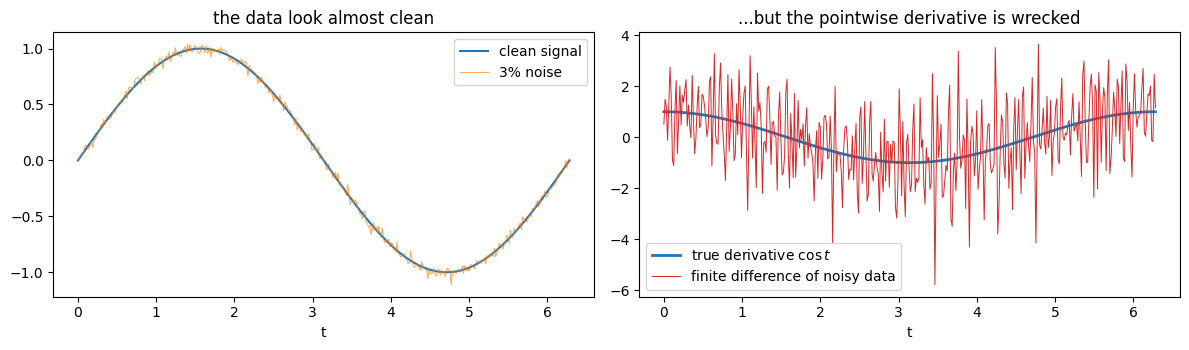

In [2]:
# why pointwise derivatives are fragile: differentiate a slightly noisy sine
tt = np.linspace(0, 2*np.pi, 400); dt = tt[1]-tt[0]
clean = np.sin(tt)
noisy = clean + 0.03*np.random.default_rng(0).standard_normal(tt.size)
d_true = np.cos(tt)
d_fd   = np.gradient(noisy, dt)        # finite difference of noisy data

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].plot(tt, clean, label="clean signal"); ax[0].plot(tt, noisy, lw=0.7, alpha=0.7, label="3% noise")
ax[0].set_title("the data look almost clean"); ax[0].legend(); ax[0].set_xlabel("t")
ax[1].plot(tt, d_true, label=r"true derivative $\cos t$", lw=2)
ax[1].plot(tt, d_fd, lw=0.7, color="C3", label="finite difference of noisy data")
ax[1].set_title("...but the pointwise derivative is wrecked"); ax[1].legend(); ax[1].set_xlabel("t")
plt.tight_layout(); plt.show()

## 2 · From strong to weak (the recipe)

Pick a smooth **test function** $\phi$ and ask the equation to hold not pointwise but *on average,
weighted by $\phi$* — i.e. after multiplying by $\phi$ and integrating. Because integration is the
inverse of differentiation, we can then **integrate by parts** to move derivatives off the
solution and onto $\phi$.

**For the ODE** $\dot x=f(x)$, multiply by $\phi$ and integrate over $[a,b]$:

$$\int_a^b \phi\,\dot x\,dt=\int_a^b \phi\,f(x)\,dt
\;\xrightarrow{\text{by parts}}\;
\underbrace{\big[\phi x\big]_a^b}_{=\,0}-\int_a^b \dot\phi\,x\,dt=\int_a^b \phi\,f(x)\,dt .$$

If $\phi(a)=\phi(b)=0$ the boundary term vanishes and we get

$$\boxed{\;-\int \dot\phi\,x\,dt=\int \phi\,f(x)\,dt\;}$$

The left side now contains **no derivative of the data** — the derivative is on the *known* $\phi$.

A function $x$ that satisfies this for *every* $\phi$ in a chosen test space is called a **weak
solution**. Two payoffs:

* **Lower smoothness:** $x$ no longer needs the derivatives that appear in the strong form (each
  integration by parts trades one derivative on the data for one on $\phi$). Weak solutions exist
  even with kinks/shocks.
* **Noise averaging:** an integral of zero-mean noise against a bounded $\phi$ shrinks like the
  test-function norm, instead of blowing up like a finite difference.

### What makes a good test function?

* **Smooth** — each derivative we want to move onto $\phi$ must exist (move a 2nd derivative ⇒
  need $\phi\in C^2$). Smoother $\phi$ also decays faster in frequency (next section), filtering
  more noise.
* **Compactly supported (or rapidly decaying)** — so the integration-by-parts **boundary terms
  vanish** ($\phi=0$ at the ends) and each $\phi$ probes a *local* piece of the data.
* **Many of them** — we use a whole family $\{\phi_k\}$ (translates and/or different shapes) to get
  one equation per $\phi_k$, then solve the resulting linear system. This is the **Galerkin** idea:
  test the equation against a basis of the test space.

## 3 · Families of test functions

| family | formula (on its support) | support | smoothness | local/global | typical use |
|---|---|---|---|---|---|
| **Piecewise-poly bump** | $(1-\tau^2)^p$ | compact $[-1,1]$ | $C^{p-1}$ | local | **weak SINDy** (Messenger–Bortz) |
| **$C^\infty$ bump (mollifier)** | $e^{-1/(1-\tau^2)}$ | compact $[-1,1]$ | $C^\infty$ | local | distribution theory, smoothing |
| **Hat / B-spline** | $\max(0,1-\lvert\tau\rvert)$ | compact | $C^0$ (hat) | local | **finite elements** |
| **Gaussian** | $e^{-\tau^2/2}$ | $\mathbb R$ (decaying) | $C^\infty$ | ~local | kernel methods |
| **Fourier mode** | $\sin/\cos(k\pi\tau)$ | whole domain | $C^\infty$ | global | spectral / periodic Galerkin |
| **Legendre / Chebyshev** | $P_n(\tau)$ | whole domain | $C^\infty$ | global | spectral methods |

The first three are **compactly supported** — so, placed strictly inside the integration domain,
their integration-by-parts boundary terms vanish automatically; the global families (Fourier,
orthogonal polynomials) instead rely on periodicity or boundary conditions to kill the boundary
term. Weak SINDy favors the **piecewise-polynomial bump**: compact, with an
analytic derivative and a smoothness/locality you can dial with $p$ and the support radius.

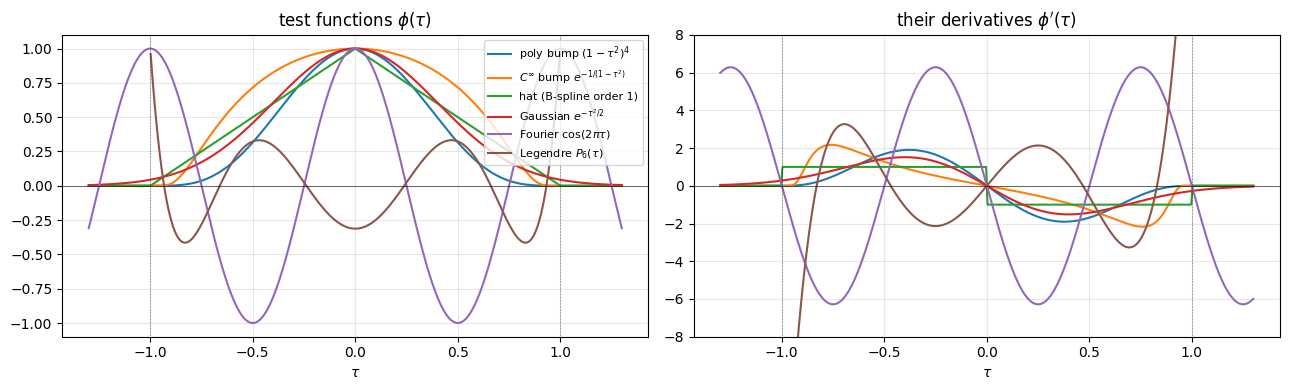

In [3]:
tau = np.linspace(-1.3, 1.3, 1000)
def poly_bump(t, p=4):
    return np.where(np.abs(t) < 1, (1 - np.clip(t**2, 0, 1))**p, 0.0)
def cinf_bump(t):
    out = np.zeros_like(t); m = np.abs(t) < 1
    out[m] = np.exp(-1.0/(1 - t[m]**2)); return out/np.exp(-1.0)   # normalize peak to 1
def hat(t):
    return np.clip(1 - np.abs(t), 0, None)
def gaussian(t, s=0.4):
    return np.exp(-(t/s)**2/2)
fams = {
    r"poly bump $(1-\tau^2)^4$": poly_bump(tau, 4),
    r"$C^\infty$ bump $e^{-1/(1-\tau^2)}$": cinf_bump(tau),
    "hat (B-spline order 1)": hat(tau),
    r"Gaussian $e^{-\tau^2/2}$": gaussian(tau),
    r"Fourier $\cos(2\pi\tau)$": np.cos(2*np.pi*tau),
    r"Legendre $P_6(\tau)$": np.where(np.abs(tau) <= 1, eval_legendre(6, np.clip(tau,-1,1)), np.nan),
}
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for name, f in fams.items():
    ax[0].plot(tau, f, label=name)
    ax[1].plot(tau, np.gradient(f, tau), label=name)
ax[0].set_title(r"test functions $\phi(\tau)$"); ax[1].set_title(r"their derivatives $\phi'(\tau)$")
for a in ax:
    a.axvline(-1, color="k", lw=0.4, ls=":"); a.axvline(1, color="k", lw=0.4, ls=":")
    a.axhline(0, color="k", lw=0.4); a.set_xlabel(r"$\tau$"); a.grid(alpha=0.3)
ax[1].set_ylim(-8, 8)   # global Legendre has large edge derivatives ($P_6'(\pm1)=\pm21$); clip for readability
ax[0].legend(fontsize=8, loc="upper right"); plt.tight_layout(); plt.show()

### Smoothness ⇒ spectral decay ⇒ noise filtering

Testing against $\phi$ is a convolution, and convolution multiplies in frequency by
$\hat\phi$. So $\phi$ acts as a **filter** whose shape is its Fourier transform. The rule of thumb:
**the smoother the test function, the faster $\hat\phi$ decays**, so the more high-frequency noise
the weak inner product suppresses.

* hat ($C^0$): $\lvert\hat\phi\rvert\sim f^{-2}$ — slow decay (leaks high-frequency noise);
* poly bump ($C^{p-1}$): $\sim f^{-(p+1)}$ — tunable via $p$;
* $C^\infty$ bump & Gaussian: faster-than-any-power decay — strongest noise suppression.

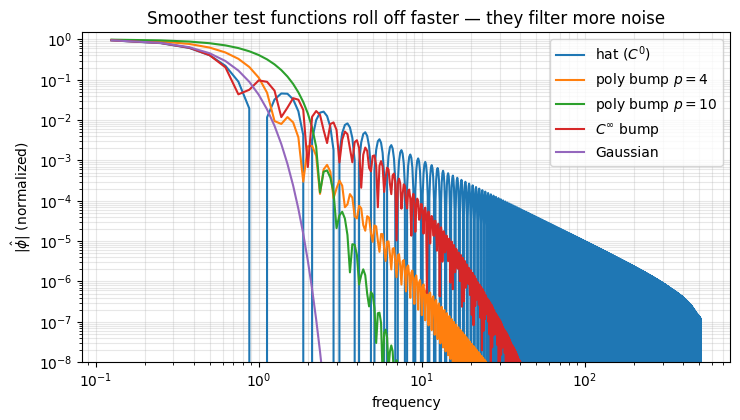

In [4]:
N = 8192; span = 8.0
xx = np.linspace(-span/2, span/2, N); dxx = xx[1]-xx[0]
freq = np.fft.rfftfreq(N, dxx)
specs = {
    "hat ($C^0$)": hat(xx),
    "poly bump $p=4$": poly_bump(xx, 4),
    "poly bump $p=10$": poly_bump(xx, 10),
    r"$C^\infty$ bump": cinf_bump(xx),
    "Gaussian": gaussian(xx, 0.4),
}
plt.figure(figsize=(7.5, 4.3))
for name, f in specs.items():
    F = np.abs(np.fft.rfft(f)); F /= F.max()
    plt.loglog(freq[1:], F[1:], label=name)
plt.xlabel("frequency"); plt.ylabel(r"$|\hat\phi|$ (normalized)")
plt.title("Smoother test functions roll off faster — they filter more noise")
plt.ylim(1e-8, 1.5); plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 4 · The weak form of an **ODE** (this is weak SINDy)

For data-driven discovery we expand the unknown $f$ in a library $f(x)=\sum_j \xi_j\,\theta_j(x)$
(e.g. polynomials). The weak equation for each test function $\phi_k$ becomes **linear in the
coefficients** $\xi_j$:

$$-\int \dot\phi_k\,x\,dt=\sum_j \xi_j\int \phi_k\,\theta_j(x)\,dt
\qquad\Longrightarrow\qquad b=G\,\xi,$$

with $b_k=-\int\dot\phi_k\,x\,dt$ and $G_{kj}=\int\phi_k\,\theta_j(x)\,dt$. Discretize the integrals
by quadrature on the samples; solve for a *sparse* $\xi$. Below we assemble it by hand on the
**logistic equation** $\dot x = x - x^2$ — the only derivative used is the analytic $\dot\phi_k$.

In [5]:
# data from the logistic ODE  x' = x - x^2
t = np.linspace(0, 12, 1500)
sol = solve_ivp(lambda tt, x: [x[0]*(1-x[0])], (t[0], t[-1]), [0.05], t_eval=t, rtol=1e-10, atol=1e-10)
X = sol.y.T                                  # shape (1500, 1)

# build K compactly-supported bump test functions phi_k and their analytic derivatives
Phi, Phidot, centers = weak.test_function_matrices(t, K=60, p=6, support_fraction=0.08)
Theta, names = libraries.polynomial_library(X, degree=2)   # columns: 1, x0, x0^2

G = Phi @ Theta            # G[k,j] = ∫ phi_k * theta_j(x) dt
b = -Phidot @ X            # b[k]   = -∫ phi_k' * x dt
xi = solvers.stlsq(G, b, threshold=0.2)

print(f"G is {G.shape} (one row per test function), b is {b.shape}")
print("recovered:  x' =", " ".join(f"{c:+.3f}*{n}" for c, n in zip(xi[:,0], names) if abs(c) > 1e-8))
print("true:       x' = +1.000*x0 -1.000*x0 x0")

G is (60, 3) (one row per test function), b is (60, 1)
recovered:  x' = +1.000*x0 -1.000*x0 x0
true:       x' = +1.000*x0 -1.000*x0 x0


## 5 · The weak form of a **PDE** (heat equation)

Now $u_t=\nu\,u_{xx}$ on $(x,t)$. Use a **space–time** test function $\phi(x,t)$, compactly
supported so all boundary terms vanish, and integrate by parts in *each* variable — moving the
$t$-derivative and *both* $x$-derivatives onto $\phi$:

$$\iint \phi\,u_t\,dx\,dt=\nu\iint \phi\,u_{xx}\,dx\,dt
\;\Longrightarrow\;
-\iint \phi_t\,u\;dx\,dt=\nu\iint \phi_{xx}\,u\;dx\,dt .$$

For a **library of candidate terms** the same trick applies: linear terms move all their
derivatives onto $\phi$; a nonlinear flux like $u\,u_x=\tfrac12\,(u^2)_x$ moves the *outer*
derivative onto $\phi$ and evaluates $u^2$ pointwise:
$\iint\phi\,u u_x=-\tfrac12\iint\phi_x\,u^2$. No spatial or temporal derivative ever touches the
data. We use a **separable** bump $\phi(x,t)=g(x)\,h(t)$, so $\phi_t=g\,h'$, $\phi_x=g'\,h$,
$\phi_{xx}=g''\,h$.

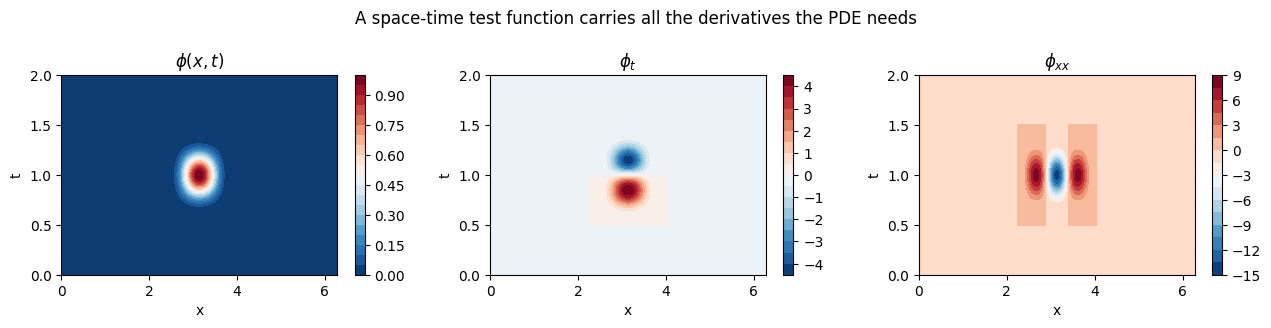

In [6]:
# A separable space-time bump and the derivatives the weak form needs.
def bump(coord, c, r, p):
    # returns phi, phi', phi''  for phi=(1-tau^2)^p, tau=(coord-c)/r
    tau = (coord - c)/r
    inside = np.abs(tau) < 1.0
    g = np.zeros_like(coord); g1 = np.zeros_like(coord); g2 = np.zeros_like(coord)
    s = tau[inside]
    g[inside]  = (1 - s**2)**p
    g1[inside] = (-2*p*s/r) * (1 - s**2)**(p-1)
    g2[inside] = (2*p/r**2) * (1 - s**2)**(p-2) * ((2*p-1)*s**2 - 1)
    return g, g1, g2

Lx, Tt = 2*np.pi, 2.0
xv = np.linspace(0, Lx, 220); tv = np.linspace(0, Tt, 220)
gx, gx1, gx2 = bump(xv, Lx/2, 0.9, 6)
ht, ht1, _   = bump(tv, Tt/2, 0.5, 6)
PHI   = np.outer(ht,  gx)     # phi(x,t)
PHI_t = np.outer(ht1, gx)     # phi_t
PHI_xx= np.outer(ht,  gx2)    # phi_xx
fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))
for a, F, ttl in zip(ax, [PHI, PHI_t, PHI_xx], [r"$\phi(x,t)$", r"$\phi_t$", r"$\phi_{xx}$"]):
    im = a.contourf(xv, tv, F, levels=20, cmap="RdBu_r"); a.set_title(ttl); a.set_xlabel("x"); a.set_ylabel("t")
    fig.colorbar(im, ax=a)
plt.suptitle("A space-time test function carries all the derivatives the PDE needs"); plt.tight_layout(); plt.show()

In [7]:
# Exact heat-equation data (each Fourier mode decays like e^{-nu k^2 t}); then weak recovery.
NU = 0.1
Nx, Nt = 128, 200
x = np.linspace(0, Lx, Nx, endpoint=False); t2 = np.linspace(0, Tt, Nt)
rng = np.random.default_rng(0); ks = np.array([1,2,3,4]); a = rng.normal(size=4); bb = rng.normal(size=4)
U = np.zeros((Nt, Nx))
for i, ti in enumerate(t2):
    U[i] = sum(np.exp(-NU*k*k*ti)*(a[m]*np.cos(k*x) + bb[m]*np.sin(k*x)) for m, k in enumerate(ks))

def weak_pde_system(U, x, t, Kx=10, Kt=8, p=6, noise=0.0, seed=0):
    Nt, Nx = U.shape; dx = x[1]-x[0]; dt = t[1]-t[0]
    if noise > 0:
        U = U + np.random.default_rng(seed).normal(scale=noise*np.sqrt(np.mean(U**2)), size=U.shape)
    U2 = U**2
    rx, rt = 0.12*(x[-1]-x[0]+dx), 0.12*(t[-1]-t[0])
    xc = np.linspace(rx, (x[-1]+dx)-rx, Kx); tc = np.linspace(t[0]+rt, t[-1]-rt, Kt)
    wt = np.full(Nt, dt); wt[0] *= 0.5; wt[-1] *= 0.5
    G, b = [], []; names = ["u", "u_x", "u_xx", "u^2", "u u_x"]
    for tcj in tc:
        h, h1, _ = bump(t, tcj, rt, p); hw, h1w = h*wt, h1*wt
        for xci in xc:
            g, g1, g2 = bump(x, xci, rx, p); gw, g1w, g2w = g*dx, g1*dx, g2*dx
            b.append(-(h1w @ U @ gw))                    # -∫∫ phi_t u  (weak u_t)
            G.append([ hw @ U @ gw,                      # u
                      -(hw @ U @ g1w),                   # u_x   = -∫ g' h u
                       hw @ U @ g2w,                     # u_xx  =  ∫ g'' h u
                       hw @ U2 @ gw,                     # u^2
                      -0.5*(hw @ U2 @ g1w)])             # u u_x = -1/2 ∫ g' h u^2
    return np.array(G), np.array(b)[:, None], names

for noise in (0.0, 0.05):
    G, b, names = weak_pde_system(U, x, t2, noise=noise)
    s = np.linalg.norm(G, axis=0)
    xi = (solvers.stlsq(G/s, b, threshold=0.05) / s[:, None])[:, 0]
    print(f"noise={noise:>4.0%}  recovered:  u_t =", " ".join(f"{c:+.4f}*{n}" for c, n in zip(xi, names) if abs(c) > 1e-6))
print(f"                 true:       u_t = {NU:+.4f}*u_xx")

noise=  0%  recovered:  u_t = +0.1000*u_xx
noise=  5%  recovered:  u_t = +0.0999*u_xx
                 true:       u_t = +0.1000*u_xx


**What just happened.** From noisy snapshots of $u(x,t)$ we recovered $u_t=\nu\,u_{xx}$ with
the right single term and $\nu\approx0.1$ — *without ever differentiating the data in space or
time.* Every derivative was applied analytically to the smooth bump $\phi$; the data only ever
appear inside integrals as $u$ and $u^2$. (This is exactly the weak-SINDy-for-PDEs idea of
Messenger & Bortz, *J. Comput. Phys.* 2021.)

## 6 · Summary — why weak beats strong

| | strong form | weak form |
|---|---|---|
| derivatives of data | required (finite differences) | **none** — all on the analytic $\phi$ |
| smoothness needed | $x\in C^k$ | much less (kinks/shocks OK) |
| noise | amplified by $1/\Delta t$ (or $1/\Delta t^2$) | **averaged down** by integration |
| boundary terms | — | vanish for compactly supported $\phi$ |
| knobs | derivative scheme | test-function family, support, degree $p$, count $K$ |

The cost is choosing the test functions — family, support radius, smoothness $p$, and how many.
For the empirical payoff of all this on real ODE discovery (and an honest accounting of the
limits), see **`02b_weak_sindy_vs_sindy.ipynb`** (full study) and **`03b_weak_sindy.ipynb`** (the
10-minute version).